# Transfer Learning con Dataset Personalizado y MobileNetV3

<a href="https://colab.research.google.com/github/andrescastro-itm/pytorch_resources/blob/main/TransferLearning/10_TransferLearning_Dataset_Personalizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En este notebook aplicamos **Transfer Learning** sobre un dataset de imágenes propio, cargado mediante una interfaz gráfica (`dl.ImageDataset`). El flujo completo es:

1. Cargar el dataset local con la GUI de `dl`
2. Dividir en conjuntos de entrenamiento, validación y prueba
3. Crear los `DataLoader` para cada subconjunto
4. Explorar un batch visualmente
5. Cargar **MobileNetV3-Small** preentrenado desde `timm`
6. **Enfoque 1 — Feature Extraction**: congelar el backbone y entrenar solo el clasificador
7. **Enfoque 2 — Fine-Tuning**: entrenar la red completa con SGD + scheduler

## Configuración del entorno

Activamos `autoreload` para que los módulos auxiliares (`dl`, `helper_*`) se recarguen automáticamente al modificarlos, sin necesidad de reiniciar el kernel.

In [1]:
%load_ext autoreload
%autoreload 2

## Instalación de dependencias

`torchsummary` permite imprimir un resumen detallado de la arquitectura del modelo (capas, dimensiones de salida y número de parámetros), similar al `model.summary()` de Keras.

In [2]:
#!pip install torchsummary timm --quiet

## Importación de librerías

- **`dl`**: módulo propio que expone una interfaz gráfica para seleccionar y cargar un dataset de imágenes local. `dl.ImageDataset()` abre la GUI y retorna un objeto compatible con la API de `torch.utils.data.Dataset`.
- **`helper_*`**: módulos auxiliares con funciones reutilizables para entrenar, evaluar y graficar (misma interfaz que en los notebooks anteriores).
- **`timm`**: librería *PyTorch Image Models* con cientos de arquitecturas preentrenadas en ImageNet.

In [3]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.functional as F
import timm
import matplotlib.pyplot as plt

from torchsummary import summary
from torch.utils.data import DataLoader, random_split

# Módulo propio: interfaz gráfica para cargar dataset local
import dl

# Helpers reutilizables (misma API que notebooks anteriores)
from helper_evaluate import compute_accuracy
from helper_train import train_model
from helper_plotting import plot_training_loss, plot_accuracy

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda:0


## Hiperparámetros globales

Definimos los valores que controlan el entrenamiento en un solo lugar para facilitar su ajuste.

In [4]:
BATCH_SIZE  = 32
NUM_EPOCHS  = 10
LEARNING_RATE = 0.01

## 1. Carga del Dataset con la GUI

`dl.ImageDataset()` abre una ventana de selección donde puedes apuntar a la carpeta raíz de tu dataset. Espera la estructura estándar de PyTorch/ImageFolder:

```
raiz/
├── clase_A/
│   ├── imagen1.jpg
│   └── imagen2.jpg
└── clase_B/
    ├── imagen3.jpg
    └── imagen4.jpg
```

El objeto retornado es un `Dataset` estándar de PyTorch: soporta `len()` e indexación `[i]`, y retorna pares `(imagen_tensor, etiqueta_int)`.

In [5]:
# Abre la GUI para seleccionar la carpeta del dataset local
dataset = dl.ImageDataset()
print(f"Total de imágenes cargadas: {len(dataset)}")

Total de imágenes cargadas: 12258


## 2. División Train / Validación / Test

Dividimos el dataset completo en tres subconjuntos:

| Subconjunto | Proporción | Uso |
|---|---|---|
| **Train** | 80 % | Actualizar los pesos del modelo |
| **Validación** | 10 % | Monitorear el rendimiento por época (sin actualizar pesos) |
| **Test** | 10 % | Evaluación final imparcial (se toca una sola vez) |

`random_split` garantiza que la división sea aleatoria y sin solapamiento.

In [6]:
total    = len(dataset)
n_train  = int(round(total * 0.80))
n_valtest = total - n_train
n_val    = int(n_valtest * 0.50)
n_test   = n_valtest - n_val

train_set, valtest_set = random_split(dataset, [n_train, n_valtest])
val_set,   test_set    = random_split(valtest_set, [n_val, n_test])

print(f"Train:      {len(train_set):>5} imágenes ({len(train_set)/total:.0%})")
print(f"Validación: {len(val_set):>5} imágenes ({len(val_set)/total:.0%})")
print(f"Test:       {len(test_set):>5} imágenes ({len(test_set)/total:.0%})")

Train:       9806 imágenes (80%)
Validación:  1226 imágenes (10%)
Test:        1226 imágenes (10%)


## 3. Creación de los DataLoaders

El `DataLoader` envuelve cada subset y gestiona el armado de batches, el mezclado y la carga paralela con múltiples workers.

- `shuffle=True` solo en entrenamiento: mezcla el orden en cada época para evitar que el modelo memorice el orden de los datos.
- `drop_last=True` en validación: descarta el último batch incompleto para evitar problemas con BatchNorm si el batch quedara con un solo elemento.
- `num_workers=2` en entrenamiento: carga los datos en paralelo al entrenamiento para no generar cuello de botella en CPU.

In [7]:
train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    drop_last=True
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE
)

print(f"Batches en train:      {len(train_loader)}")
print(f"Batches en validación: {len(val_loader)}")
print(f"Batches en test:       {len(test_loader)}")

Batches en train:      307
Batches en validación: 38
Batches en test:       39


## 4. Exploración de un Batch

Inspeccionamos las dimensiones del primer batch para confirmar que los tensores tienen la forma esperada por el modelo antes de comenzar a entrenar.

In [8]:
# Tomamos un batch de prueba
images, labels = next(iter(train_loader))

print(f"Forma del batch de imágenes: {images.shape}")
# → [BATCH_SIZE, canales, alto, ancho]
print(f"Forma del batch de etiquetas: {labels.shape}")
print(f"Etiquetas en este batch: {labels.tolist()}")

Forma del batch de imágenes: torch.Size([32, 3, 224, 224])
Forma del batch de etiquetas: torch.Size([32])
Etiquetas en este batch: [5, 7, 7, 8, 1, 4, 1, 8, 7, 8, 7, 4, 7, 1, 6, 9, 8, 2, 8, 2, 0, 6, 8, 7, 2, 5, 7, 7, 4, 7, 3, 6]


### Visualización del Batch

Usamos `torchvision.utils.make_grid` para ensamblar las imágenes del batch en una sola cuadrícula y visualizarlas de un vistazo.

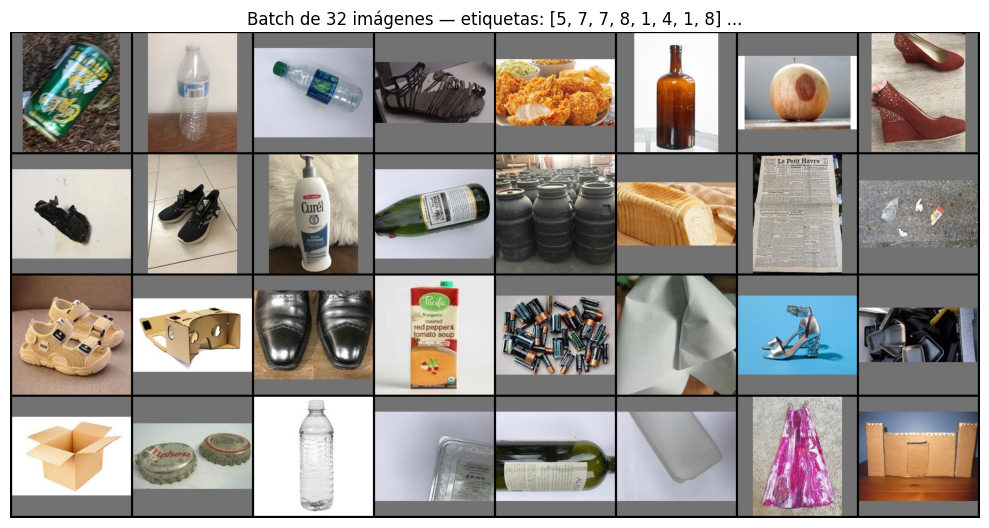

In [9]:
grid = torchvision.utils.make_grid(images, nrow=8, padding=4)

plt.figure(figsize=(10, 6))
plt.imshow(F.to_pil_image(grid))
plt.title(f"Batch de {BATCH_SIZE} imágenes — etiquetas: {labels[:8].tolist()} ...")
plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Transfer Learning con MobileNetV3

Usaremos **MobileNetV3-Small-0.5** de la librería `timm`: una arquitectura ligera y eficiente diseñada para dispositivos con recursos limitados, preentrenada en ImageNet (1.28M imágenes, 1,000 clases).

### ¿Por qué MobileNetV3?
- Muy eficiente: pocos parámetros sin sacrificar demasiada precisión
- Disponible en múltiples variantes en `timm` (`mob*`)
- Ideal para datasets pequeños donde el overfitting es una preocupación

Primero listamos las variantes disponibles en `timm` que comiencen con `mob`:

In [10]:
# Explorar variantes de MobileNet disponibles en timm
all_mobile_models = timm.list_models('mob*', pretrained=True)
print(f"Variantes de MobileNet disponibles: {len(all_mobile_models)}")
for m in all_mobile_models[:10]:
    print(f"  · {m}")

Variantes de MobileNet disponibles: 33
  · mobilenetv2_050.lamb_in1k
  · mobilenetv2_100.ra_in1k
  · mobilenetv2_110d.ra_in1k
  · mobilenetv2_120d.ra_in1k
  · mobilenetv2_140.ra_in1k
  · mobilenetv3_large_100.miil_in21k
  · mobilenetv3_large_100.miil_in21k_ft_in1k
  · mobilenetv3_large_100.ra_in1k
  · mobilenetv3_rw.rmsp_in1k
  · mobilenetv3_small_050.lamb_in1k


### Creación del Modelo

Cargamos MobileNetV3 con `timm.create_model()` y le indicamos:
- `num_classes=K`: ajusta la capa final al número de clases de nuestro dataset
- `pretrained=True`: descarga los pesos de ImageNet
- `in_chans=3`: adapta la primera capa convolucional para imágenes en **escala de grises** (1 canal) o **a color** (3 canales)

In [ ]:
model = timm.create_model(
    'mobilenetv3_small_050',
    num_classes=10,      # Número de clases de nuestro dataset
    pretrained=True,    # Cargar pesos preentrenados de ImageNet
    in_chans=3          # Imágenes en escala de grises (1 canal) o a color (3 canales)
).to(device)

print(model)

MobileNetV3(
  (conv_stem): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True
    (drop): Identity()
    (act): Hardswish()
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
        (bn1): BatchNormAct2d(
          16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): ReLU(inplace=True)
          (conv_expand): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (gate): Hardsigmoid()
        )
        (conv_pw): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): Batch

### Resumen de la Arquitectura

`summary()` muestra cada capa con su dimensión de salida y el número de parámetros. Es útil para:
- Verificar que las dimensiones de entrada/salida son correctas
- Conocer cuántos parámetros entrenables tiene el modelo
- Identificar dónde está la mayor concentración de parámetros

In [12]:
# Resumen del modelo con imágenes de 224x224 en escala de grises
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 112, 112]             432
          Identity-2         [-1, 16, 112, 112]               0
         Hardswish-3         [-1, 16, 112, 112]               0
    BatchNormAct2d-4         [-1, 16, 112, 112]              32
            Conv2d-5           [-1, 16, 56, 56]             144
          Identity-6           [-1, 16, 56, 56]               0
              ReLU-7           [-1, 16, 56, 56]               0
    BatchNormAct2d-8           [-1, 16, 56, 56]              32
            Conv2d-9              [-1, 8, 1, 1]             136
             ReLU-10              [-1, 8, 1, 1]               0
           Conv2d-11             [-1, 16, 1, 1]             144
      Hardsigmoid-12             [-1, 16, 1, 1]               0
    SqueezeExcite-13           [-1, 16, 56, 56]               0
           Conv2d-14            [-1, 8,

### Verificación del Forward Pass

Antes de entrenar, verificamos que el modelo acepta el formato de entrada correcto y produce la salida esperada (logits de dimensión `[batch, num_classes]`).

In [13]:
x = torch.randn(1, 3, 224, 224).to(device)  # Batch ficticio: 1 imagen, 3 canales, 224x224
logits = model(x)
print(f"Forma de la salida (logits): {logits.shape}")  # → [1, K]

probas = torch.nn.functional.softmax(logits, dim=-1)
print(f"Probabilidades (antes de entrenar): {probas.detach().round(decimals=4)}")

Forma de la salida (logits): torch.Size([1, 10])
Probabilidades (antes de entrenar): tensor([[0.0072, 0.0281, 0.0244, 0.0026, 0.0916, 0.0099, 0.0054, 0.0009, 0.6058,
         0.2241]], device='cuda:0')


## 6. Accuracy del Modelo Preentrenado (Sin Adaptar)

Evaluamos el modelo tal como viene de ImageNet (sin ningún entrenamiento en nuestros datos) para establecer una línea base. Con 2 clases, un modelo aleatorio daría ~50% — veremos qué tan bien o mal transfiere el conocimiento de ImageNet a nuestro dominio.

In [14]:
model = model.to(device)
acc_base = compute_accuracy(model, test_loader, device)
print(f"Accuracy inicial (modelo sin adaptar): {acc_base:.2f}%")

Accuracy inicial (modelo sin adaptar): 10.69%


## 7. Enfoque 1: Feature Extraction (Congelar Backbone)

**Estrategia:** congelamos todos los parámetros del backbone (las capas convolucionales que extraen características) y solo entrenamos la capa final (`classifier`).

**¿Por qué?**
- El backbone ya aprendió características visuales generales (bordes, texturas, formas) que son útiles para casi cualquier tarea de visión
- Con pocos datos, entrenar toda la red desde los pesos de ImageNet riesgo sobreajuste
- Es más rápido: solo se actualizan ~1K parámetros en lugar de ~1.5M

### Paso 1: Congelar todos los parámetros

In [15]:
# Congelar TODOS los parámetros del modelo
for param in model.parameters():
    param.requires_grad = False

# Verificamos: ningún parámetro debería acumular gradiente
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros entrenables: {trainable:,} / {total_params:,}")

Parámetros entrenables: 0 / 578,474


### Paso 2: Desbloquear Solo la Capa Final

Reactivamos `requires_grad` únicamente para los pesos y bias de la capa `classifier` — la única parte que se adaptará a nuestras _K_ clases.

In [16]:
# Desbloquear SOLO la capa clasificadora final
model.classifier.weight.requires_grad = True
model.classifier.bias.requires_grad   = True

# Verificamos el estado de cada parámetro
print("Parámetros y su estado requires_grad:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"ENTRENABLE  → {name}  {list(param.shape)}")

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nParámetros entrenables: {trainable:,} / {total_params:,}")

Parámetros y su estado requires_grad:
ENTRENABLE  → classifier.weight  [10, 1024]
ENTRENABLE  → classifier.bias  [10]

Parámetros entrenables: 10,250 / 578,474


### Paso 3: Entrenamiento (Feature Extraction)

- **Adam** como optimizador: rápida convergencia para pocos parámetros
- **ReduceLROnPlateau**: reduce el learning rate automáticamente cuando el accuracy de validación deja de mejorar (factor=0.1 → divide el lr por 10)
- **scheduler_on='valid_acc'**: el scheduler monitorea el accuracy de validación para decidir cuándo bajar el lr

In [17]:
model = model.to(device)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    factor=0.1,
    mode='max'   # 'max' porque monitoreamos accuracy (queremos que suba)
)

minibatch_loss_list, train_acc_list, valid_acc_list = train_model(
    model=model,
    num_epochs=NUM_EPOCHS,
    train_loader=train_loader,
    valid_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    device=device,
    scheduler=scheduler,
    scheduler_on='valid_acc',
    logging_interval=50
)

Epoch: 001/010 | Batch 0000/0307 | Loss: 3.8726
Epoch: 001/010 | Batch 0050/0307 | Loss: 0.7312
Epoch: 001/010 | Batch 0100/0307 | Loss: 1.1249
Epoch: 001/010 | Batch 0150/0307 | Loss: 0.5267
Epoch: 001/010 | Batch 0200/0307 | Loss: 0.5553
Epoch: 001/010 | Batch 0250/0307 | Loss: 0.1803
Epoch: 001/010 | Batch 0300/0307 | Loss: 0.8266
Epoch: 001/010 | Train: 83.51% | Validation: 78.21%
Time elapsed: 1.22 min
Epoch: 002/010 | Batch 0000/0307 | Loss: 0.7719
Epoch: 002/010 | Batch 0050/0307 | Loss: 0.9675
Epoch: 002/010 | Batch 0100/0307 | Loss: 0.7511
Epoch: 002/010 | Batch 0150/0307 | Loss: 0.6328
Epoch: 002/010 | Batch 0200/0307 | Loss: 0.8092
Epoch: 002/010 | Batch 0250/0307 | Loss: 0.5332
Epoch: 002/010 | Batch 0300/0307 | Loss: 0.6529
Epoch: 002/010 | Train: 86.18% | Validation: 77.88%
Time elapsed: 2.45 min
Epoch: 003/010 | Batch 0000/0307 | Loss: 0.5631
Epoch: 003/010 | Batch 0050/0307 | Loss: 0.3104
Epoch: 003/010 | Batch 0100/0307 | Loss: 0.3423
Epoch: 003/010 | Batch 0150/0307 |

### Resultados: Feature Extraction

Visualizamos la curva de pérdida y el accuracy de entrenamiento/validación a lo largo de las épocas.

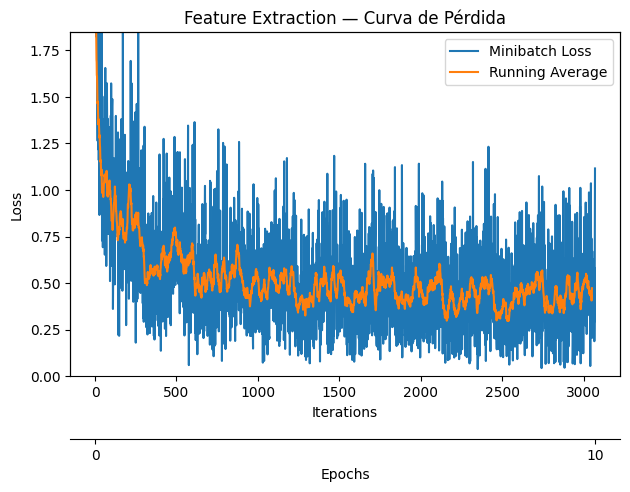

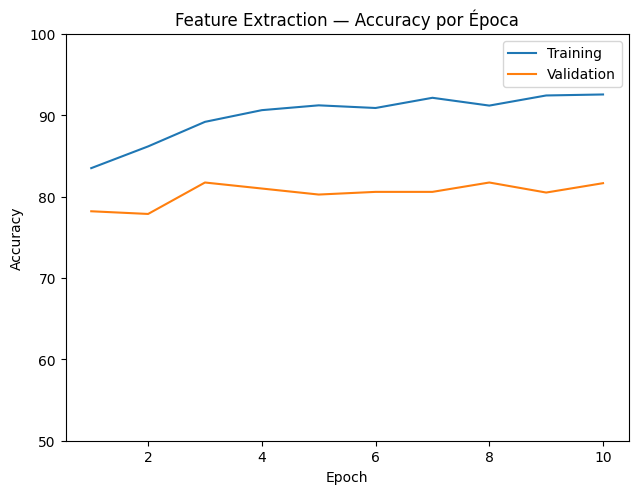

In [18]:
plot_training_loss(minibatch_losses=minibatch_loss_list, num_epochs=NUM_EPOCHS, averaging_iterations=20)
plt.title("Feature Extraction — Curva de Pérdida")
plt.show()

plot_accuracy(train_acc=train_acc_list, valid_acc=valid_acc_list)
plt.title("Feature Extraction — Accuracy por Época")
plt.ylim([50, 100])
plt.show()

In [19]:
acc_fe = compute_accuracy(model, test_loader, device)
print(f"Accuracy en test (Feature Extraction): {acc_fe:.2f}%")

Accuracy en test (Feature Extraction): 81.40%


## 8. Enfoque 2: Fine-Tuning (Entrenar la Red Completa)

**Estrategia:** descargamos un modelo nuevo con todos los pesos desbloqueados y entrenamos toda la red — incluyendo el backbone — con una tasa de aprendizaje pequeña.

**¿Por qué lr pequeño?**
- Los pesos del backbone ya son buenos (ImageNet). Un lr grande los destruiría
- Queremos *ajustar fino* (fine-tune), no reinicializar
- **SGD + momentum** es la elección clásica para fine-tuning completo: más estable que Adam cuando se actualiza toda la red

In [20]:
# Nuevo modelo con TODOS los parámetros desbloqueados (por defecto)
model_ft = timm.create_model(
    'mobilenetv3_small_050',
    num_classes=10,
    pretrained=True,
    in_chans=3
)

# Verificamos que todos tienen requires_grad=True
trainable = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_ft.parameters())
print(f"Parámetros entrenables: {trainable:,} / {total_params:,}  (todos desbloqueados)")

Parámetros entrenables: 578,474 / 578,474  (todos desbloqueados)


### Entrenamiento (Fine-Tuning)

In [21]:
model_ft = model_ft.to(device)

optimizer_ft = torch.optim.SGD(
    model_ft.parameters(),
    momentum=0.9,
    lr=LEARNING_RATE
)

scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    factor=0.1,
    mode='max'
)

minibatch_loss_list_ft, train_acc_list_ft, valid_acc_list_ft = train_model(
    model=model_ft,
    num_epochs=NUM_EPOCHS,
    train_loader=train_loader,
    valid_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer_ft,
    device=device,
    scheduler=scheduler_ft,
    scheduler_on='valid_acc',
    logging_interval=50
)

Epoch: 001/010 | Batch 0000/0307 | Loss: 3.6148
Epoch: 001/010 | Batch 0050/0307 | Loss: 1.4406
Epoch: 001/010 | Batch 0100/0307 | Loss: 1.4288
Epoch: 001/010 | Batch 0150/0307 | Loss: 0.9677
Epoch: 001/010 | Batch 0200/0307 | Loss: 0.9445
Epoch: 001/010 | Batch 0250/0307 | Loss: 0.9172
Epoch: 001/010 | Batch 0300/0307 | Loss: 0.6031
Epoch: 001/010 | Train: 70.29% | Validation: 69.65%
Time elapsed: 1.29 min
Epoch: 002/010 | Batch 0000/0307 | Loss: 0.6317
Epoch: 002/010 | Batch 0050/0307 | Loss: 1.1035
Epoch: 002/010 | Batch 0100/0307 | Loss: 1.4706
Epoch: 002/010 | Batch 0150/0307 | Loss: 0.7598
Epoch: 002/010 | Batch 0200/0307 | Loss: 0.3751
Epoch: 002/010 | Batch 0250/0307 | Loss: 0.7559
Epoch: 002/010 | Batch 0300/0307 | Loss: 0.6474
Epoch: 002/010 | Train: 48.68% | Validation: 47.78%
Time elapsed: 2.60 min
Epoch: 003/010 | Batch 0000/0307 | Loss: 0.4831
Epoch: 003/010 | Batch 0050/0307 | Loss: 0.4133
Epoch: 003/010 | Batch 0100/0307 | Loss: 0.4851
Epoch: 003/010 | Batch 0150/0307 |

### Resultados: Fine-Tuning

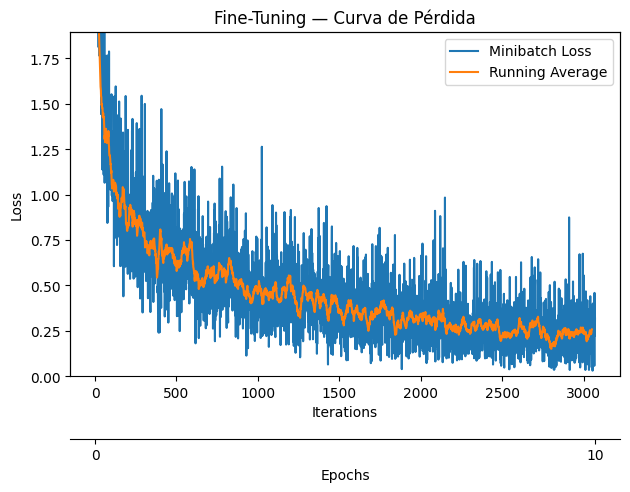

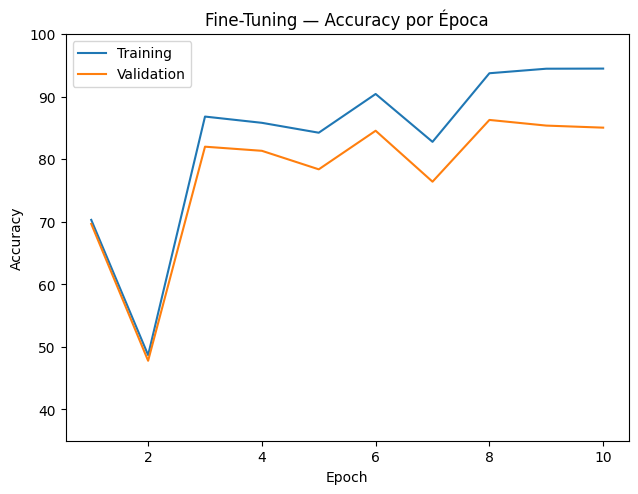

In [22]:
plot_training_loss(minibatch_losses=minibatch_loss_list_ft, num_epochs=NUM_EPOCHS, averaging_iterations=20)
plt.title("Fine-Tuning — Curva de Pérdida")
plt.show()

plot_accuracy(train_acc=train_acc_list_ft, valid_acc=valid_acc_list_ft)
plt.title("Fine-Tuning — Accuracy por Época")
plt.ylim([35, 100])
plt.show()

In [23]:
acc_ft = compute_accuracy(model_ft, test_loader, device)
print(f"Accuracy en test (Fine-Tuning): {acc_ft:.2f}%")

Accuracy en test (Fine-Tuning): 85.48%


## 9. Comparativa Final

Resumimos los resultados de ambos enfoques para decidir cuál conviene usar según el contexto.

In [24]:
print("=" * 50)
print("       COMPARATIVA DE RESULTADOS")
print("=" * 50)
print(f"  Modelo sin adaptar (baseline): {acc_base:.2f}%")
print(f"  Feature Extraction (Adam):     {acc_fe:.2f}%")
print(f"  Fine-Tuning (SGD + momentum):  {acc_ft:.2f}%")
print("=" * 50)
print()
print("Regla práctica:")
print("  · Pocos datos + dominio similar → Feature Extraction")
print("  · Más datos o dominio distinto  → Fine-Tuning")

       COMPARATIVA DE RESULTADOS
  Modelo sin adaptar (baseline): 10.69%
  Feature Extraction (Adam):     81.40%
  Fine-Tuning (SGD + momentum):  85.48%

Regla práctica:
  · Pocos datos + dominio similar → Feature Extraction
  · Más datos o dominio distinto  → Fine-Tuning


## Conclusiones

1. **`dl.ImageDataset()`** permite cargar cualquier dataset local de imágenes con estructura de carpetas sin escribir una clase `Dataset` personalizada.
2. **`random_split`** divide el dataset de forma reproducible en train / val / test con las proporciones deseadas.
3. **Feature Extraction** es más rápido y robusto cuando los datos son escasos: solo entrena ~1K parámetros de los ~1.5M del modelo.
4. **Fine-Tuning** permite adaptar incluso las capas profundas del backbone, a costa de más tiempo de entrenamiento y mayor riesgo de sobreajuste con pocos datos.
5. **`ReduceLROnPlateau`** ajusta automáticamente el learning rate cuando el modelo deja de mejorar, evitando quedar atascado en un mínimo local.
